# ❒ squarenet: memory packing
post processing step after the fit for up to *3 speed in future requests


In [1]:
from squarenet import SquareNet
import numpy as np
import matplotlib.pyplot as plt

## Let start as usual: create the cloud, fit the grid...

In [2]:
N = 250_000  
D = 2         

dataraw = {"points": np.random.rand(N, D), "colors": np.random.rand(N, 3)}

IJ = (500, 500)
I, J = IJ
rawnet = SquareNet(IJ_=IJ)
rawnet.fit(dataraw["points"])

succesfully sorted at iteration 11


## Now you can pack your dataset 📦
- Which only means to permute your indexes in a structured, squarnet friendly way.
- If you need to rebuild initial indexes
- -> datapack[name][n] = dataraw[name][sigma[n]]

In [3]:
datapack = {}
for name, data in dataraw.items() :
    datapack[name] = rawnet.map(data).reshape(N, -1).copy()

print(datapack.keys())
# saving the sigma permutation
sigma = rawnet.grid.flatten()

dict_keys(['points', 'colors'])


In [4]:
def show_packing(raw, pack, sigma):
    N = len(raw)
    I = int(np.sqrt(N))
    step = max(1, I // 10)

    rows = np.arange(0, I, step)
    cols = np.arange(0, I, step)

    rr, cc = np.meshgrid(rows, cols)

    packsel = (rr * I + cc).ravel()
    rawsel = np.sort(sigma[packsel])

    packs = pack[packsel]
    raws = raw[rawsel]


    #coordinates
    px, py = packs[::-1, 0], packs[:, 1]
    rx, ry = raws[::-1, 0], raws[:, 1]

    fig, ax = plt.subplots(1, 2, figsize=(6, 6))

    ax[0].plot(rx, ry, label="raw")
    ax[0].set_title("Raw")
    ax[0].set_aspect("equal")
    ax[0].set_xticks([])
    ax[0].set_yticks([])

    ax[1].plot(px, py, label="packed", color = "green")
    ax[1].set_title("Packed")
    ax[1].set_aspect("equal")
    ax[1].set_xticks([])
    ax[1].set_yticks([])

    plt.show()

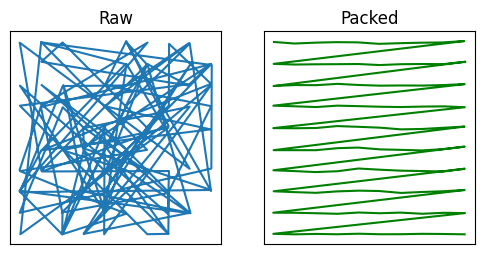

In [5]:
raw, pack = dataraw["points"], datapack["points"]
show_packing(raw, pack, sigma)

Now, reset the squarenet. It will detect packing and boost any spatial functionality based on map and invert_map.

📖 Think your packed dataset as a book: 
- No more need to follow the messy raw pass in memory
- -> SquareNet simply reads it page by page in natural contiguous order

In [6]:
packnet = SquareNet(IJ_ = IJ)
packnet.fit(datapack["points"])

Successfully sorted at iteration 0...
...Which means data are allready packed
Performing an autopack to boost performance.


Just don't mix yourself between raw and packed  worlds...

❌ DON'T do that!
```python
big_mistake = rawnet.map(datapack["colors"])
big_mistake = packnet.map(dataraw["colors"])
```
✅ This is good
```python
ok = rawnet.map(dataraw["colors"])
ok = packnet.map(datapack["colors"])
```


## Benchmarking ⏱️

- Suppose we want to compute, for each point, the average color in a local neighborhood.
- Let’s see how long it takes on the raw color dataset versus the "book-like" indexed one.

In [7]:
import time

wr = 4
ws = 2*wr +1

for world, data, net in zip(
    ["raw", "packed"], 
    [dataraw, datapack], 
    [rawnet, packnet]
):
    net.warnings_ = False #unactive warning
    start = time.time()
    for _ in range(10):
        X = data["colors"] #(N, 3)
        Xview = net.views(X, wr = wr, invert_map = True) #(N, 3, ws, ws)
        Y = (Xview**2).mean(axis = (-2, -1))
    print(world, "runtime:", f"{(time.time()-start):.2f}")


raw runtime: 16.19
packed runtime: 5.59


## Next step ❯❯❯❯ :
![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)[ 03_advanced_heuristics.ipynb](https://colab.research.google.com/github/ArmanddeCacqueray/SquareNet/blob/main/exemples/03_advanced_heuristics.ipynb)
Play with advanced spatial heuristics to leverage:
- Zsquare ability to fit the most puzzling geometries 🧩
- GSquare ability to fit a dataset given as a graph 🕸️ 